# CircLS pipeline, end to end: twistedghz_8

GHZ chain with S twists, 8 qubits -- paper benchmark; the twists make re-selection consume |Y> ancilla patches; compiled with the paper's keep policy (the data patches hold the state to the end).  QASM → NWQEC (Pauli product rotations) → Y-free → **CircLS PPM
sequence** → placement + ancilla-path routing (the 3D spacetime
structure) → TQEC block graph where expressible → stim circuits (clean /
noisy, d = 3, 5, 7) → measured logical error rate.  Artifacts land in
`data/`, `figures/`, `stim/`, `blockgraph/`.

## 1. The logical circuit

In [1]:
import pathlib, sys
HERE = pathlib.Path.cwd()
ROOT = HERE.parents[2]
for p in (str(ROOT), str(ROOT / "experiments"), str(HERE.parents[1] / "tools")):
    if p not in sys.path:
        sys.path.insert(0, p)
for sub in ("data", "figures", "stim"):
    (HERE / sub).mkdir(exist_ok=True)

qasm = pathlib.Path("data/1_twistedghz_8.qasm").read_text()
GATES = [l for l in qasm.splitlines()
         if l and not l.startswith(("OPENQASM", "include", "qreg", "creg", "measure"))]
print("GHZ chain with S twists, 8 qubits -- paper benchmark; the twists make re-selection consume |Y> ancilla patches; compiled with the paper's keep policy (the data patches hold the state to the end)")
print(f"{len(GATES)} Clifford gates")
print(qasm)

GHZ chain with S twists, 8 qubits -- paper benchmark; the twists make re-selection consume |Y> ancilla patches; compiled with the paper's keep policy (the data patches hold the state to the end)
16 Clifford gates
OPENQASM 2.0;
include "qelib1.inc";
qreg q[8];
h q[0];
cx q[0],q[1];
s q[1];
h q[1];
cx q[1],q[2];
cx q[2],q[3];
s q[3];
h q[3];
cx q[3],q[4];
cx q[4],q[5];
s q[5];
h q[5];
cx q[5],q[6];
cx q[6],q[7];
s q[7];
h q[7];
creg c[8];
measure q -> c;



## 2. NWQEC output: Pauli product rotations + terminal measurements (PBC)

In [2]:
from circls.interop.nwqec.frontend import load_pbc
from nb_helpers import show_ops, save_ops
pbc = load_pbc(qasm, keep_cx=True)
save_ops(pbc, "data/2_twistedghz_8_nwqec_pbc.txt")
show_ops(pbc, limit=16, tail=8)

$(X \otimes X \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1})_{\pi/4}$  
$(\mathbb{1} \otimes Z \otimes X \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1})_{-\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes Y \otimes X \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1})_{\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z \otimes X \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1})_{-\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Y \otimes X \otimes \mathbb{1} \otimes \mathbb{1})_{\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z \otimes X \otimes \mathbb{1})_{-\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Y \otimes X)_{\pi/4}$  
$X \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1}$ measurement  
$-\mathbb{1} \otimes Z \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1}$ measurement  
$\mathbb{1} \otimes \mathbb{1} \otimes Y \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1}$ measurement  
$-\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1}$ measurement  
$\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Y \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1}$ measurement  
$-\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z \otimes \mathbb{1} \otimes \mathbb{1}$ measurement  
$\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Y \otimes \mathbb{1}$ measurement  
$-\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z$ measurement

## 3. Y-free rewrite

In [3]:
from circls.interop.ir.yfree import to_y_free
yfree = to_y_free(pbc)
save_ops(yfree, "data/3_twistedghz_8_yfree_ppr.txt")
show_ops(yfree, limit=4, tail=4)

$(X \otimes X \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1})_{\pi/4}$  
$(\mathbb{1} \otimes Z \otimes X \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1})_{\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes Z \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1})_{\pi/4}$  
$(\mathbb{1} \otimes \mathbb{1} \otimes X \otimes X \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1})_{\pi/4}$  
... (27 ops total, full list in data/)  
$(\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z \otimes \mathbb{1})_{\pi/4}$  
$\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes X \otimes \mathbb{1}$ measurement  
$(\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z \otimes \mathbb{1})_{-\pi/4}$  
$-\mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes \mathbb{1} \otimes Z$ measurement

## 4. CircLS compilation: the executed PPM sequence

In [4]:
import contextlib, io
from circls.pipeline import compile_qasm
from nb_helpers import ppm_step_lines, save_ppm_sequence

# paper keep policy for this consumable-protocol case: the data
# patches hold the twisted-GHZ state to the end; the |Y> ancillas
# are the consumables and retire
def compile_d(d):
    with contextlib.redirect_stdout(io.StringIO()):
        return compile_qasm(qasm, distance=d, assignment="optimized",
                            liveness=True, keep_patches={'q0', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7'})

cp3 = compile_d(3)
raw = load_pbc(qasm, keep_cx=False)
steps = cp3.experiment.ppm_sequence
save_ppm_sequence(raw, steps, "data/4_twistedghz_8_ppm_sequence.txt")
print(f"{len(raw.ops)} raw terminal measurements -> {len(steps)} executed PPMs")
print("\n".join(ppm_step_lines(steps)))

8 raw terminal measurements -> 4 executed PPMs
PPM 0: q1.Z  y0.Z
PPM 1: q3.Z  y1.Z
PPM 2: q5.Z  y2.Z
PPM 3: q7.Z  y3.Z


## 5. Placement, routed ancilla paths, and the 3D spacetime structure

12 patches placed, 4 PPM steps (4 joint) routed; full detail in 5_twistedghz_8_placement_routing.json


3D structure: 5_twistedghz_8_spacetime.png (103.7 blocks)


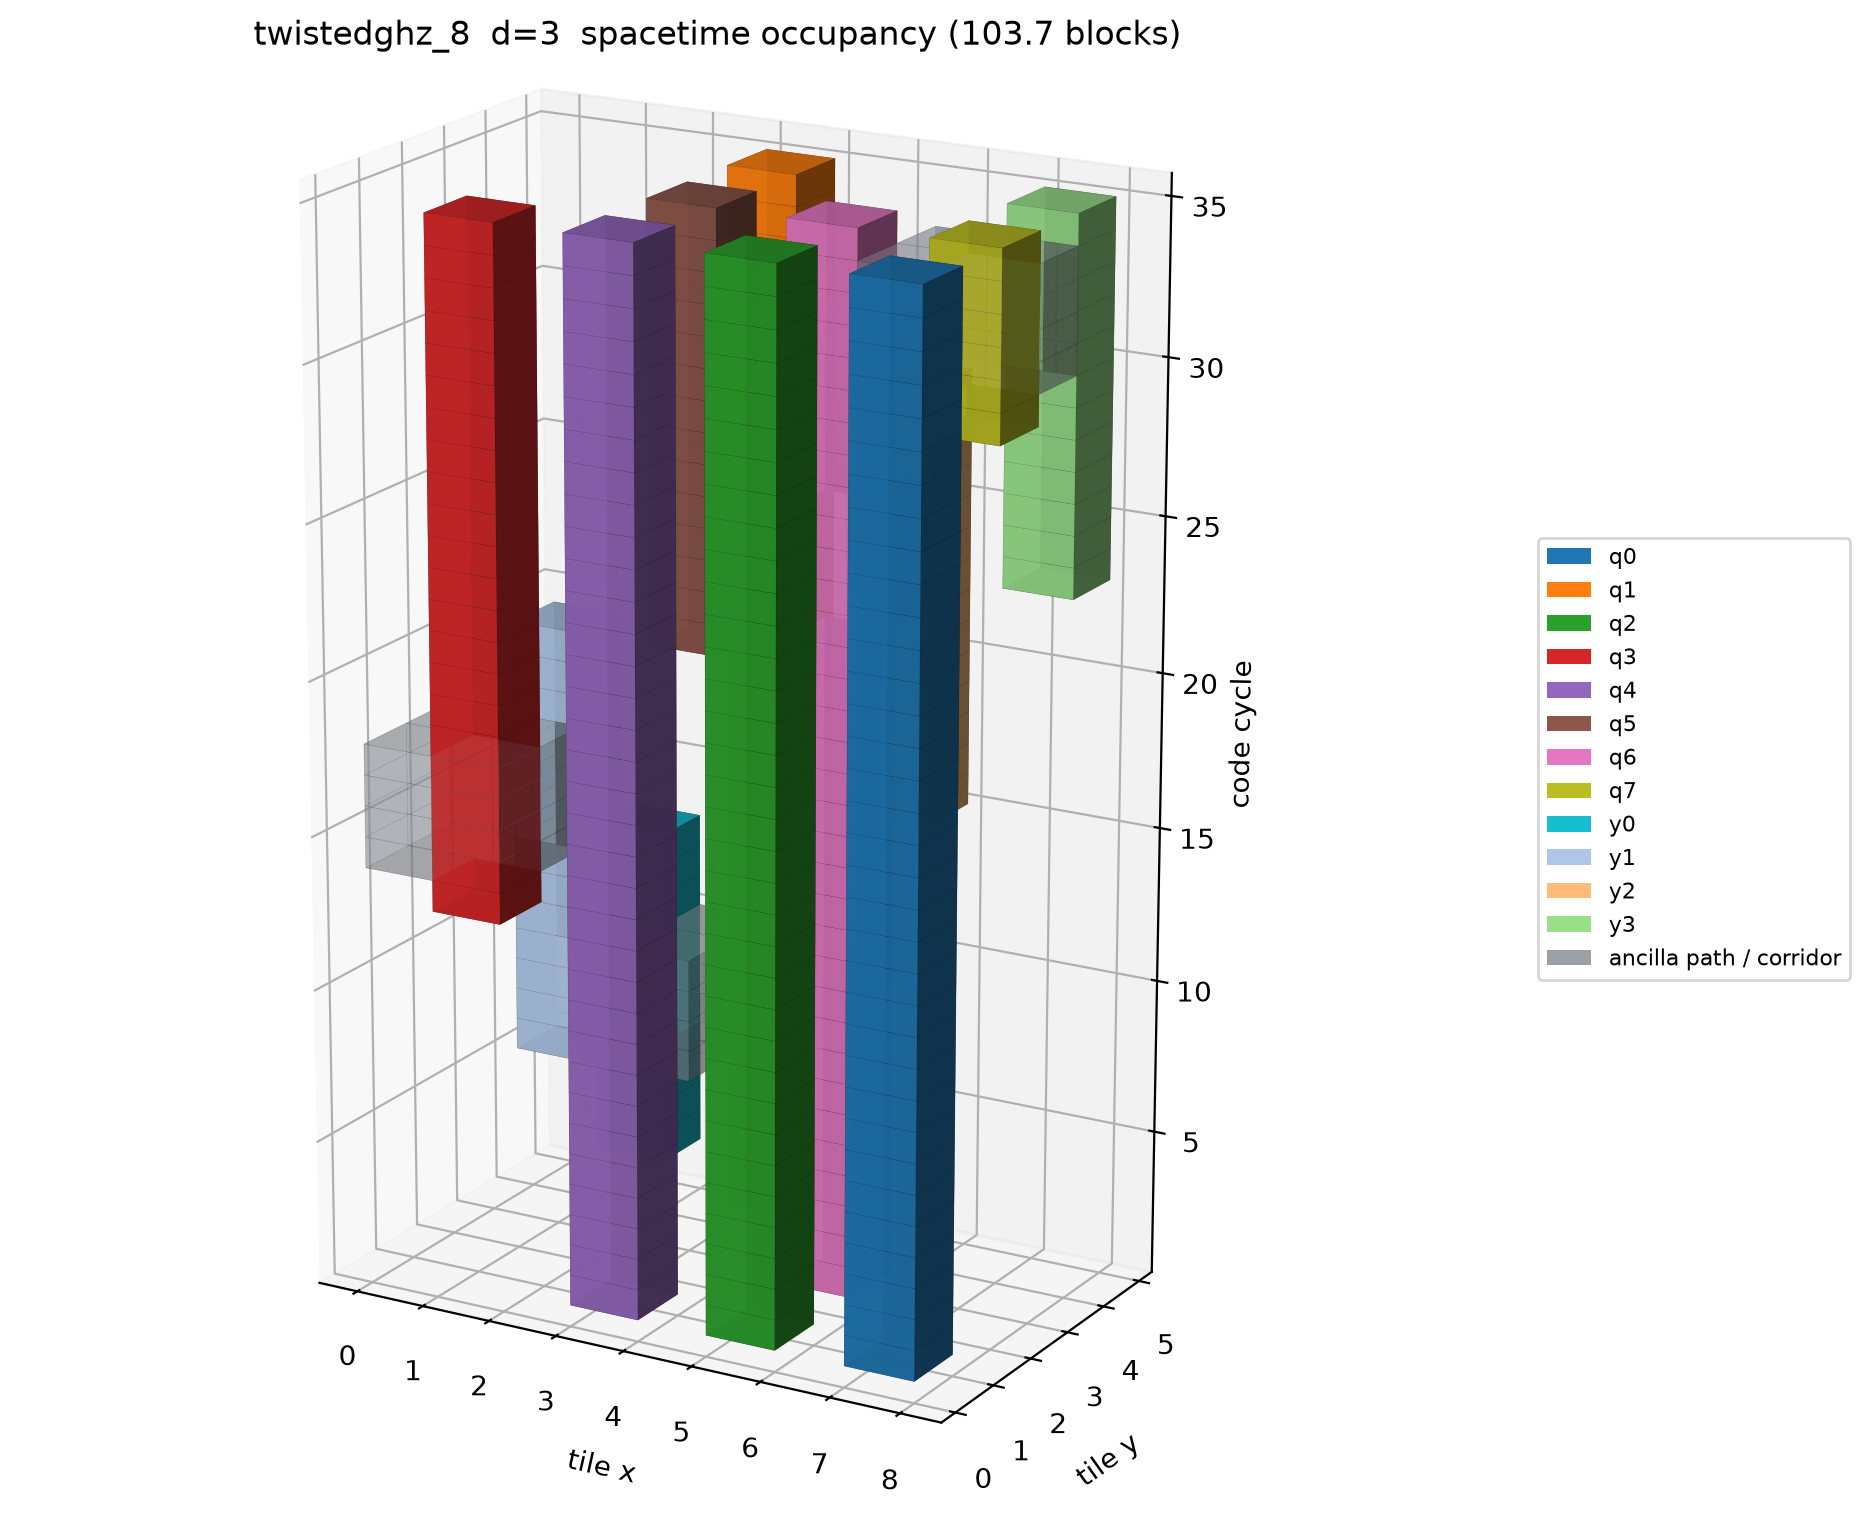

In [5]:
from circls.metrics.experiment_stats import experiment_stats
from render_spacetime import render
from nb_helpers import save_routing

print(save_routing(cp3, steps, "data/5_twistedghz_8_placement_routing.json"))
stats = experiment_stats(cp3.experiment, cp3.circuit)
png, js, _ = render(stats, cp3.placement, "twistedghz_8", str(HERE / "figures"), distance=3)
import shutil
shutil.move(str(HERE / "figures" / "twistedghz_8_schedule.json"),
            str(HERE / "data" / "5_twistedghz_8_schedule.json"))
png2 = str(HERE / "figures" / "5_twistedghz_8_spacetime.png")
shutil.move(png, png2); png = png2
print("3D structure:", pathlib.Path(png).name, f"({stats.volume_blocks:.1f} blocks)")
from IPython.display import Image, display
display(Image(png, width=640))

## 6. TQEC block-graph export (rotatable)

In [6]:
import os
from export_blockgraph_auto import auto_export
auto_export(cp3, "twistedghz_8", HERE / "blockgraph",
            tqec_python=os.environ.get("TQEC_PYTHON"))
BG = HERE / "blockgraph"
from IPython.display import IFrame, display
hits = sorted(BG.glob("*_blockgraph.html"))
if hits:
    print(f"-> blockgraph/{hits[0].name} -- drag to rotate "
          f"(the .dae loads into tqec / SketchUp)")
    display(IFrame("blockgraph/" + hits[0].name, width=760, height=480))
else:
    print()
    print((BG / "gap_note.txt").read_text())

wrote twistedghz_8_blockstructure.json: 66 cubes, 58 pipes, 32 pinned walls, 4 Y half-cube(s), 6 layers


NOT EXPORTED -- 8 distinct seam-side variant(s) tried; last: NOT EXPORTED: every valid assignment has zero deterministic parities -- the searched geometry does not express this protocol.
(full search log: blockgraph/export_log.txt)

twistedghz_8 reaches TQEC's wall rules (valid ZXCube assignments exist)
but no assignment carries a deterministic correlation surface: the
protocol consumes |Y>-initialized ancilla patches (born as tqec's
temporal Y half-cube, Z-joined, then read out in X), and the plain
temporal-Y endpoint cannot carry the consumption protocol's
deterministic parities.  This is robust to the embedding: the exporter
searched all 8 distinct seam-side contact variants (216 wall-valid
assignments in total) -- every one wall-valid, every one with zero
deterministic surfaces.  tqec's own tracker marks this corner open
("Y cube is not implemented" in the fixed-boundary builder; issue
#967, rotated Y half-cube .dae import).  Geometry in
twistedghz_8_blockstructure.json, per-varian

## 7. stim circuits: clean and noisy, d=3, 5, 7

In [7]:
from noise_inject import inject_uniform_noise
P_NOISY = 1e-3
circuits = {}
for d in (3, 5, 7):
    cp = cp3 if d == 3 else compile_d(d)
    clean = cp.circuit
    circuits[d] = clean
    (HERE / "stim" / f"d{d}").mkdir(exist_ok=True)
    pathlib.Path(f"stim/d{d}/7_twistedghz_8_clean.stim").write_text(str(clean))
    pathlib.Path(f"stim/d{d}/7_twistedghz_8_noisy_p1e-3.stim").write_text(
        str(inject_uniform_noise(clean, P_NOISY)))
    print(f"d={d}: {clean.num_qubits} qubits, {clean.num_detectors} detectors, "
          f"{clean.num_observables} observables")

d=3: 518 qubits, 1990 detectors, 6 observables


d=5: 1354 qubits, 8276 detectors, 6 observables


d=7: 2574 qubits, 21162 detectors, 6 observables


## 8. Measured logical error rate of the CircLS-compiled circuits

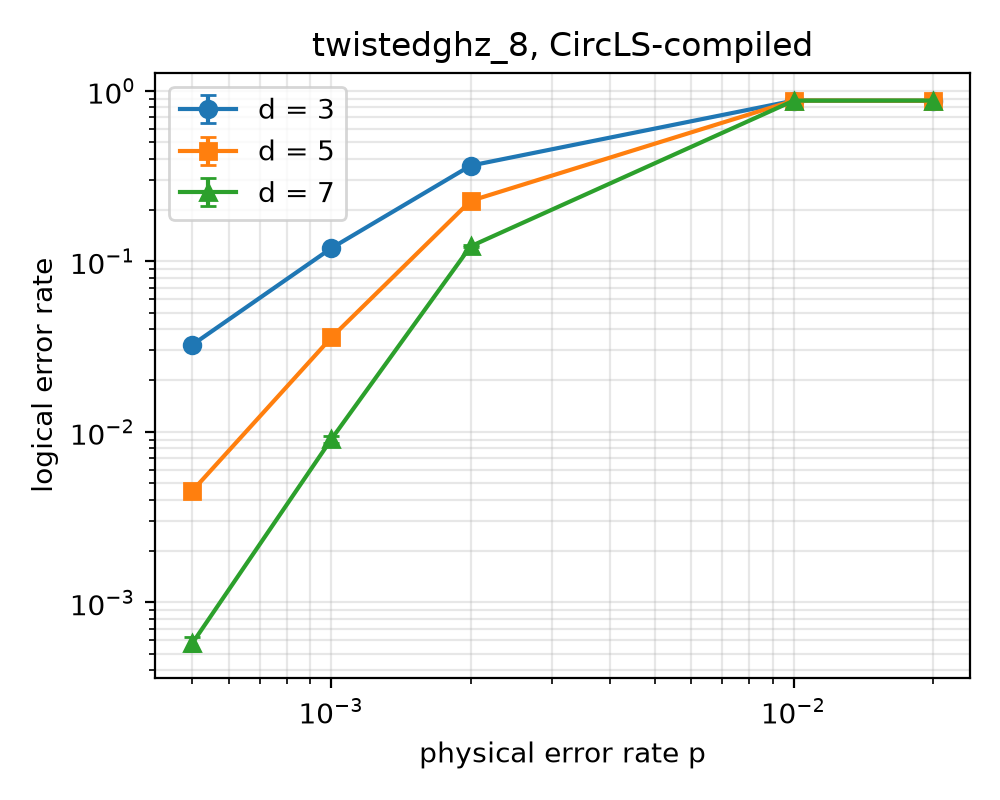

In [8]:
from ler_sampler import measure_ler
from nb_helpers import save_ler_points, plot_ler

PS = [5e-4, 1e-3, 2e-3, 1e-2, 2e-2]
WORKERS = 32     # parallel sampling processes -- set to your machine
points = {(d, p): measure_ler(inject_uniform_noise(clean, p), workers=WORKERS)
          for d, clean in circuits.items() for p in PS}
save_ler_points(points, "data/8_twistedghz_8_ler_points.json")
plot_ler(points, PS, "twistedghz_8, CircLS-compiled", "figures/8_twistedghz_8_ler.png")
from IPython.display import Image, display
display(Image("figures/8_twistedghz_8_ler.png", width=560))